<a href="https://colab.research.google.com/github/dharshinikumaravel2004-byte/ecg-classification-resnet/blob/main/categorical_crossentropy_weighted_Loss_(RESNET).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, BatchNormalization, GlobalAveragePooling1D, Add, Input, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

TRAIN_PATH = "/content/drive/MyDrive/mit dataset/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/mit dataset/mitbih_test.csv"  # FIXED

train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Mounted at /content/drive
Train shape: (87554, 188)
Test shape: (21892, 188)


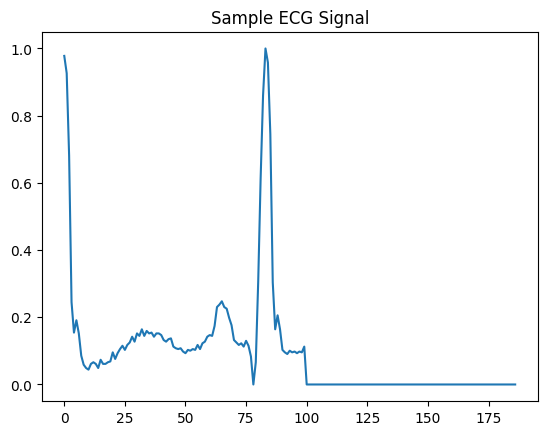

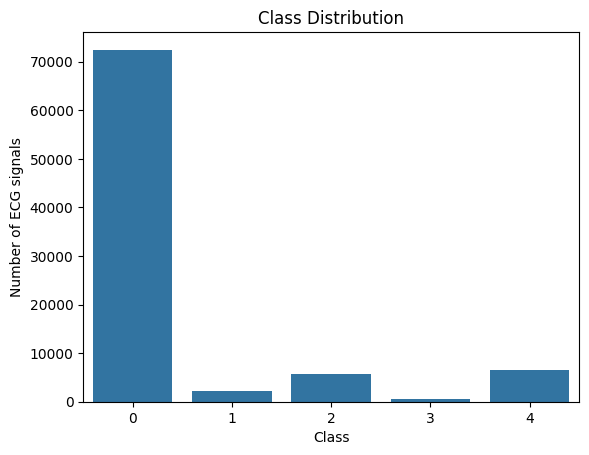

0
0


In [ ]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0,1,2,3,4]

sns.barplot(x=classes, y=counts.values)
plt.xlabel("Class")
plt.ylabel("Number of ECG signals")
plt.title("Class Distribution")
plt.show()

print(train.isna().sum().sum())
print(test.isna().sum().sum())

In [ ]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

In [ ]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE:
187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_res),
    y=y_res
)

class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0)}


In [ ]:
X_res = np.array(X_res).reshape(-1, 187, 1)
X_test = np.array(X_test).reshape(-1, 187, 1)

In [ ]:
# Convert to one-hot
y_res_cat = to_categorical(y_res, 5)
y_test_cat = to_categorical(y_test, 5)



In [ ]:
def resnet_block(x, filters, stride=1):

    shortcut = x

    x = Conv1D(filters, 3, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv1D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)

    return x

In [ ]:
def resnet_ecg():

    inputs = Input(shape=(187,1))

    x = Conv1D(32, 3, activation='relu')(inputs)
    x = BatchNormalization()(x)

    x = resnet_block(x, 64)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x, 128)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x, 256)

    x = GlobalAveragePooling1D()(x)

    x = Dense(128, activation='relu')(x)

    outputs = Dense(5, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_res, y_res_cat, test_size=0.2, random_state=42
)

In [ ]:
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_res, y_res)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_res[train_idx], X_res[val_idx]
    y_tr, y_va = y_res_cat[train_idx], y_res_cat[val_idx]

    model = resnet_ecg()

    model.fit(
        X_tr,
        y_tr,
        epochs=10,
        batch_size=64,
        class_weight=class_weights,
        verbose=1
    )

    loss, acc = model.evaluate(X_va, y_va, verbose=0)

    print(f"Fold {fold+1} Accuracy: {acc:.4f}")

    cv_accuracies.append(acc)

print("\nMean CV Accuracy:", np.mean(cv_accuracies))


Fold 1
Epoch 1/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 55s 10ms/step - accuracy: 0.9447 - loss: 0.1575
Epoch 2/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9777 - loss: 0.0637
Epoch 3/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9862 - loss: 0.0408
Epoch 4/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 35s 9ms/step - accuracy: 0.9900 - loss: 0.0297
Epoch 5/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9924 - loss: 0.0226
Epoch 6/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9938 - loss: 0.0181
Epoch 7/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - accuracy: 0.9949 - loss: 0.0149
Epoch 8/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9959 - loss: 0.0123
Epoch 9/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9964 - loss: 0.0108
Epoch 10/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9967 - loss: 0.0097
Fold 1 Accuracy: 0.9541

Fold 2
Epoch 1/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 51s 10ms/step - accuracy:

In [ ]:
model = resnet_ecg()

history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val_final, y_val_final),
    epochs=10,
    batch_size=64
)

Epoch 1/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 66s 12ms/step - accuracy: 0.9513 - loss: 0.1385 - val_accuracy: 0.9481 - val_loss: 0.1460
Epoch 2/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 45s 10ms/step - accuracy: 0.9814 - loss: 0.0541 - val_accuracy: 0.8897 - val_loss: 0.3929
Epoch 3/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 45s 10ms/step - accuracy: 0.9884 - loss: 0.0343 - val_accuracy: 0.7225 - val_loss: 1.3835
Epoch 4/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 44s 10ms/step - accuracy: 0.9919 - loss: 0.0245 - val_accuracy: 0.9523 - val_loss: 0.1719
Epoch 5/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 44s 10ms/step - accuracy: 0.9936 - loss: 0.0198 - val_accuracy: 0.9273 - val_loss: 0.2956
Epoch 6/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 45s 10ms/step - accuracy: 0.9949 - loss: 0.0153 - val_accuracy: 0.9711 - val_loss: 0.0785
Epoch 7/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 45s 10ms/step - accuracy: 0.9959 - loss: 0.0123 - val_accuracy: 0.8793 - val_loss: 0.4332
Epoch 8/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 44s 10ms/step - accuracy: 0.9964 -

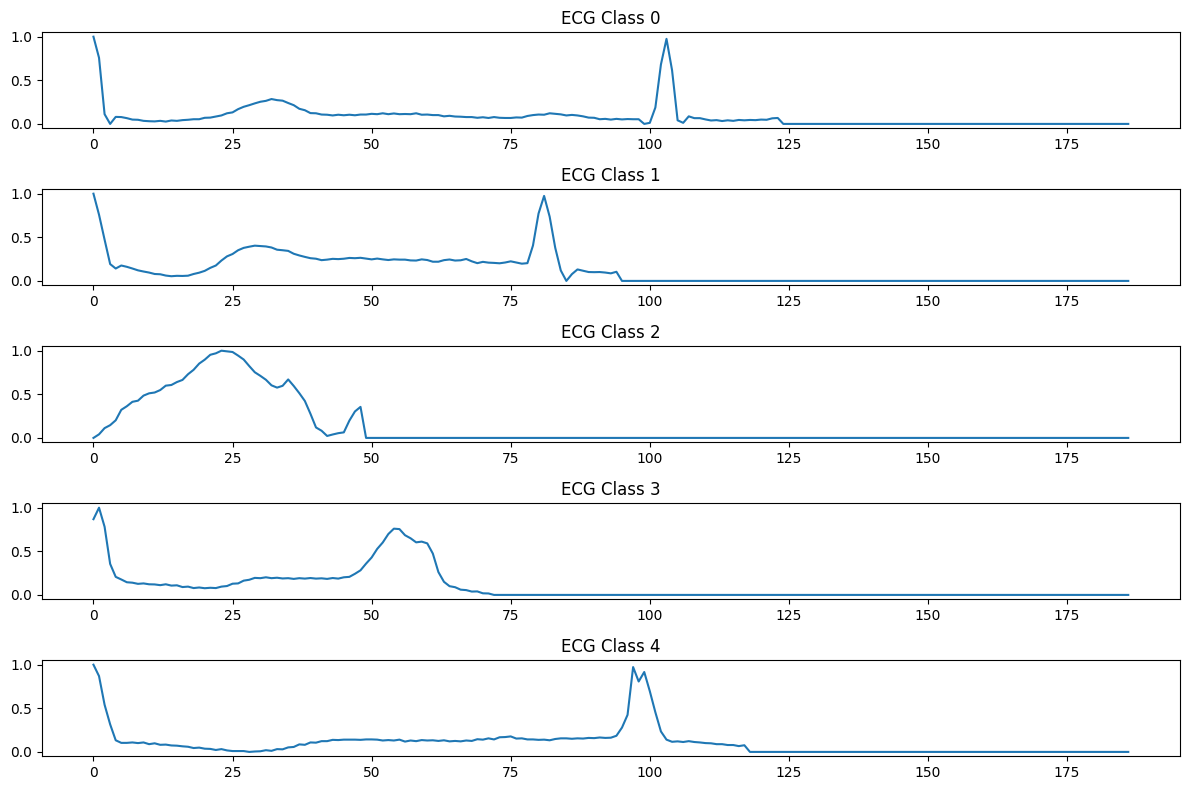

In [ ]:
plt.figure(figsize=(12,8))

for cls in range(5):
    idx = np.where(y_test == cls)[0][0]

    plt.subplot(5,1,cls+1)
    plt.plot(X_test[idx].reshape(187))
    plt.title(f"ECG Class {cls}")
    plt.tight_layout()

plt.show()

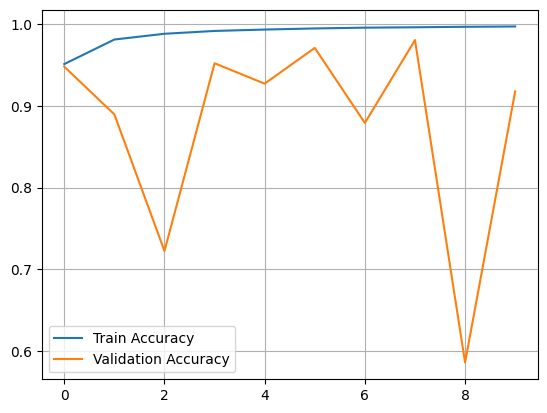

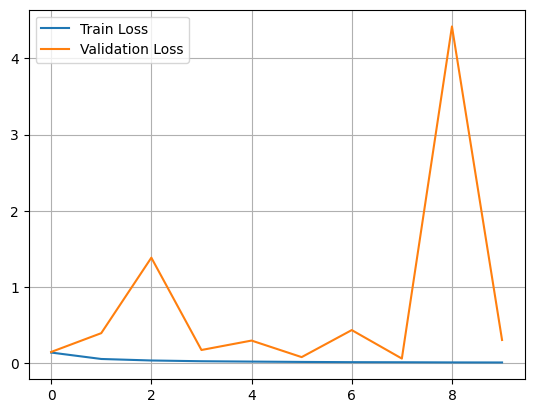

In [ ]:
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [ ]:
y_val_pred_prob = model.predict(X_va)
y_val_pred = np.argmax(y_val_pred_prob, axis=1)

y_val_true = np.argmax(y_va, axis=1)

mcc_val = matthews_corrcoef(y_val_true, y_val_pred)
print("Validation MCC:", mcc_val)

3775/3775 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step
Validation MCC: 0.9031322390832651


In [ ]:
y_pred = np.argmax(model.predict(X_test), axis=1)
print(np.unique(y_pred))

685/685 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
[0 1 2 3 4]


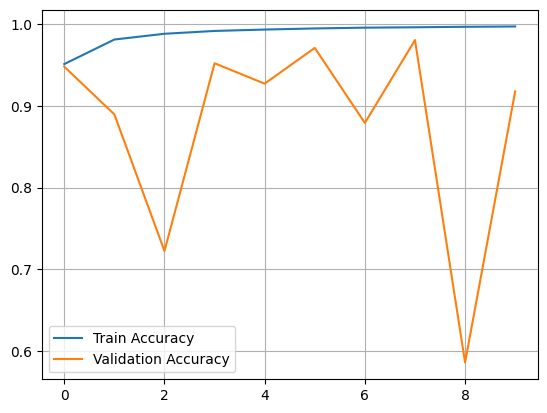

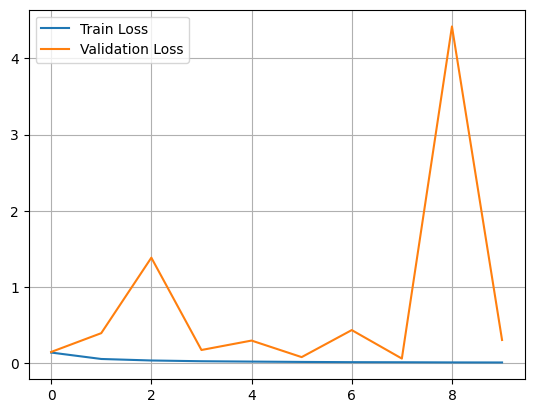

In [ ]:
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

y_test_pred = np.argmax(model.predict(X_test), axis=1)
y_test_true = np.argmax((y_test_cat + 1)//2, axis=1)

print(classification_report(y_test_true, y_test_pred))

Test Accuracy: 0.7964
685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
              precision    recall  f1-score   support

           0       0.99      0.76      0.86     18118
           1       0.11      0.93      0.20       556
           2       0.88      0.97      0.92      1448
           3       0.96      0.56      0.71       162
           4       0.93      0.99      0.96      1608

    accuracy                           0.80     21892
   macro avg       0.78      0.84      0.73     21892
weighted avg       0.96      0.80      0.86     21892



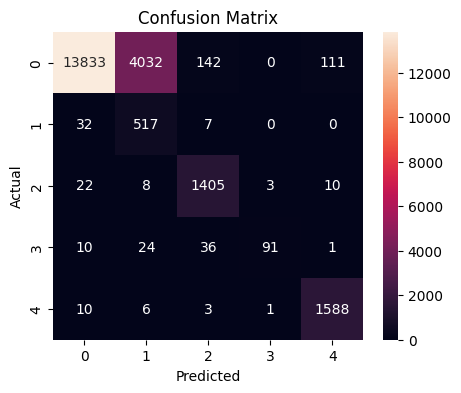

In [ ]:
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()